In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [3]:
df = pd.read_csv('/content/week7_marketing_leads.csv')

In [4]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7407 entries, 0 to 7406
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   LeadID         7407 non-null   object 
 1   Age            7407 non-null   int64  
 2   LeadSource     7407 non-null   object 
 3   Industry       7407 non-null   object 
 4   PageViews      7407 non-null   int64  
 5   TimeOnSite     7407 non-null   float64
 6   DeviceType     7407 non-null   object 
 7   SubmittedForm  7407 non-null   object 
 8   Converted      7407 non-null   int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 520.9+ KB


,0
LeadID,0
Age,0
LeadSource,0
Industry,0
PageViews,0
TimeOnSite,0
DeviceType,0
SubmittedForm,0
Converted,0


In [7]:
df.head()

,LeadID,Age,LeadSource,Industry,PageViews,TimeOnSite,DeviceType,SubmittedForm,Converted
0,LEAD00001,56,Paid Ads,Healthcare,3,4.19,Mobile,Yes,0
1,LEAD00002,46,Organic Search,Healthcare,17,13.43,Desktop,No,0
2,LEAD00003,32,Paid Ads,Healthcare,6,14.54,Desktop,No,0
3,LEAD00004,60,Social Media,Retail,24,14.25,Mobile,No,0
4,LEAD00005,25,Social Media,Technology,17,3.30,Desktop,No,0


In [5]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [6]:
df_encoded.head()

,Age,PageViews,TimeOnSite,Converted,LeadID_LEAD00002,LeadID_LEAD00003,LeadID_LEAD00004,LeadID_LEAD00005,LeadID_LEAD00006,LeadID_LEAD00007,...,LeadSource_Paid Ads,LeadSource_Referral,LeadSource_Social Media,Industry_Finance,Industry_Healthcare,Industry_Retail,Industry_Technology,DeviceType_Mobile,DeviceType_Tablet,SubmittedForm_Yes
0,56,3,4.19,0,False,False,False,False,False,False,...,True,False,False,False,True,False,False,True,False,True
1,46,17,13.43,0,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,32,6,14.54,0,False,True,False,False,False,False,...,True,False,False,False,True,False,False,False,False,False
3,60,24,14.25,0,False,False,True,False,False,False,...,False,False,True,False,False,True,False,True,False,False
4,25,17,3.30,0,False,False,False,True,False,False,...,False,False,True,False,False,False,True,False,False,False


In [8]:
X = df_encoded.drop('Converted', axis=1)
y = df_encoded['Converted']


In [10]:
X.shape

(7407, 7420)

In [11]:
y.shape

(7407,)

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)


In [14]:
X_train.shape

(5184, 7420)

In [15]:
X_test.shape

(2223, 7420)

In [16]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)


In [17]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.650472334682861
              precision    recall  f1-score   support

           0       0.71      0.86      0.78      1568
           1       0.30      0.15      0.20       655

    accuracy                           0.65      2223
   macro avg       0.51      0.50      0.49      2223
weighted avg       0.59      0.65      0.61      2223



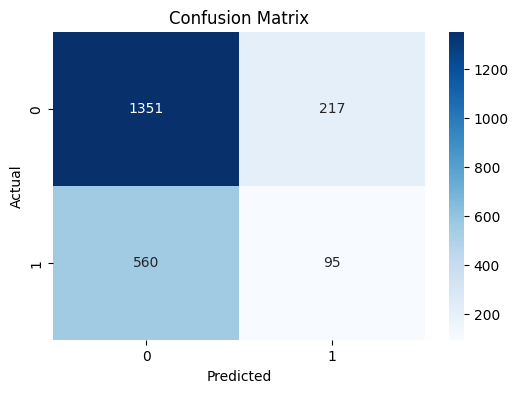

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [21]:
df.to_csv("/content/week7_marketing_leads.csv", index=False)
